# Check if any of the observed activities where __better__ than the additive model would suggest.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("white")
sns.set_context("talk")

In [3]:
high_order = pd.read_excel("data/round0_1_compiled.xlsx")

In [4]:
high_order

,Mutations,FC relative to WT
0,Additive_A420S|T561K,0.000000
1,Additive_G556R|S407Q,0.000000
2,Additive_G556R|T561K|S425A,0.000000
3,Additive_A420S|D403N|T561K,0.000000
4,Additive_S569R|A570K,0.000000
...,...,...
283,UCB_V83W|A420R|S569F,0.000000
284,UCB_V83W|T561C|D403L,0.000000
285,UCB_A399T|V83L|A420N,0.017555
286,UCB_V83T|G556M|S569C,0.079666


In [5]:
ssm = pd.read_csv('../data/experimental/ssm_data.csv')

In [6]:
ssm_activity_dict = ssm.set_index('mutation_string')['activity'].to_dict()

In [7]:
def map_additive_prediction(mutations, type='additive'):
    mutations_string = mutations.split('_')[1]
    mutation_strings = mutations_string.split('|')
    fc_prediction = 1.0

    if type == 'additive':
        for mutation in mutation_strings:
            if mutation in ssm_activity_dict:
                fc_delta = ssm_activity_dict[mutation] - 1
                fc_prediction += fc_delta
            else:
                return None
        if fc_prediction < 0:
            return 0
    elif type == 'multiplicative':
        for mutation in mutation_strings:
            if mutation in ssm_activity_dict:
                fc_delta = ssm_activity_dict[mutation]
                fc_prediction *= fc_delta
            else:
                return None
        if fc_prediction < 0:
            return 0


    return fc_prediction

In [8]:
high_order['additive_prediction'] = high_order['Mutations'].apply(map_additive_prediction)

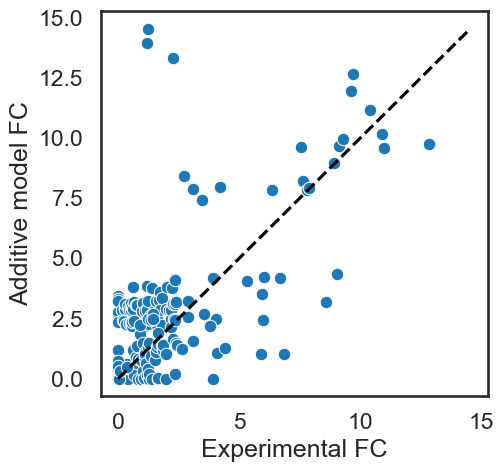

In [9]:
fig, ax = plt.subplots(figsize=(5, 5))
max_max = max(high_order[['FC relative to WT', 'additive_prediction']].max())
sns.scatterplot(data=high_order, x='FC relative to WT', y='additive_prediction', ax=ax)
ax.plot([0, max_max], [0, max_max], color='black', linestyle='--')
ax.set_xlabel('Experimental FC')
ax.set_ylabel('Additive model FC')
plt.savefig('../figures/round2/data_vs_additive_model.png', dpi=300, bbox_inches='tight')

In [10]:
high_order['Additive error'] =  high_order['additive_prediction'] - high_order['FC relative to WT']

/Users/ekomp/miniconda3/envs/aidep/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


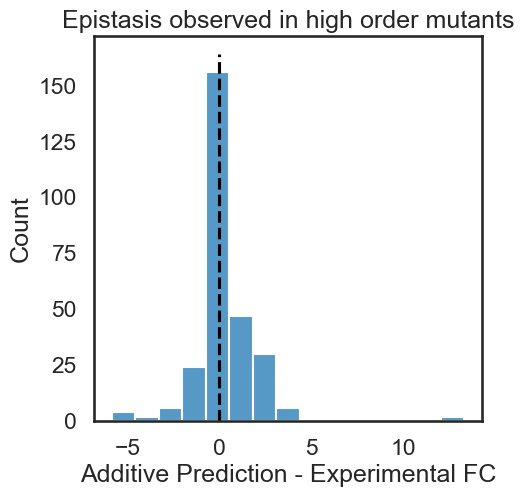

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
sns.histplot(data=high_order, x='Additive error', bins=15)
ax.set_xlabel('Additive Prediction - Experimental FC')
ax.set_title('Epistasis observed in high order mutants')
ax.vlines(0, 0, ax.get_ylim()[1], color='black', linestyle='--')
plt.savefig('../figures/round2/additive_error.png', dpi=300, bbox_inches='tight')

In [12]:
high_order['multiplicative_prediction'] = high_order['Mutations'].apply(map_additive_prediction, type='multiplicative')

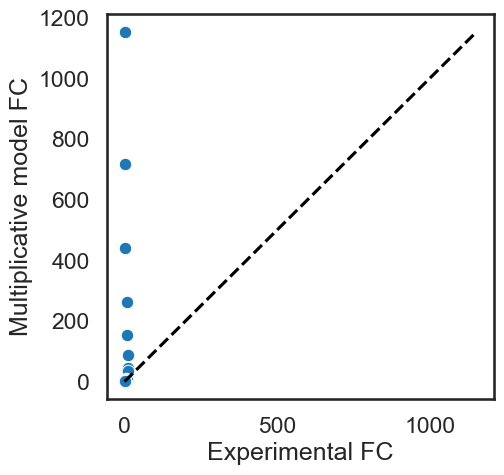

In [13]:
fig, ax = plt.subplots(figsize=(5, 5))
max_max = max(high_order[['FC relative to WT', 'multiplicative_prediction']].max())
sns.scatterplot(data=high_order, x='FC relative to WT', y='multiplicative_prediction', ax=ax)
ax.plot([0, max_max], [0, max_max], color='black', linestyle='--')
ax.set_xlabel('Experimental FC')
ax.set_ylabel('Multiplicative model FC')
plt.savefig('../figures/round2/data_vs_multiplicative_model.png', dpi=300, bbox_inches='tight')

In [55]:
high_order.sort_values('Additive error', ascending=True).head(10)

,Mutations,FC relative to WT,additive_prediction,Additive error
190,Greedy_V83A|S569A|S407A,6.859061,1.003227,-5.855835
191,Greedy_V83G|T561G|A570G,8.599122,3.172822,-5.426300
189,Greedy_V83A|S569G|S407A,5.889133,1.007556,-4.881577
86,Additive_V83G|A420S|S425A,9.042134,4.355254,-4.686881
186,Greedy_G556K|T561N|S569N,3.924288,0.000000,-3.924288
77,Additive_A399E|S425A,6.003608,2.447943,-3.555664
188,Greedy_V83A|G556A|S569P,4.407968,1.272964,-3.135004
95,Additive_A399G|V83G|T561S,12.843837,9.737164,-3.106673
187,Greedy_V83A|G556P|S569P,4.085555,1.075837,-3.009718
80,Additive_V83G|A399E|S425A,6.672357,4.197128,-2.475229


In [59]:
ssm_activity_dict['S407A']

0.9875214551852404